In [3]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from haversine import haversine, Unit
from esda.moran import Moran_Local
from pysal.lib import weights
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from merge_bus_subway import merge_subway_bus

In [4]:
# Load necessary data
weekday_subway_network = pickle.load(open('subway_network_weekday.pickle', 'rb'))
weekend_subway_network = pickle.load(open('subway_network_weekend.pickle', 'rb'))
weekday_bus_network = pickle.load(open('bus_network_weekday.pickle', 'rb'))
weekend_bus_network = pickle.load(open('bus_network_weekend.pickle', 'rb'))

G_doctor = pickle.load(open('Doctor_Network.pickle','rb'))

G_merged_weekday = merge_subway_bus(weekday_subway_network, weekday_bus_network, 0.5)
G_merged_weekend = merge_subway_bus(weekend_subway_network, weekend_bus_network, 0.5)


NYC_family_doctors = pd.read_csv(r'C:\Users\baodu\Dropbox\Summer_research_2024\nyc_doctor_review.csv', encoding='unicode_escape')
NYC_family_doctors = NYC_family_doctors.dropna(subset=['Latitude', 'Longitude','Site_Name'])

doctor_degree = pd.read_csv(r'C:\Users\baodu\Dropbox\Summer_research_2024\doctor_degree.csv')

C:\Users\baodu\AppData\Local\Temp\ipykernel_29180\3922396836.py:13: DtypeWarning: Columns (0,1,2,5,6,12,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,61,63,65,67,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,134,137,138,139,140,141,142,143,144,145,147,149,154,155,156,157,162,163,164,165,166,168,169,170,171,172,173,174,175,176,177,182,183,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291

In [5]:
station_degrees = {node : degree for node, degree in G_merged_weekday.degree()}
nx.set_node_attributes(G_merged_weekday, station_degrees, 'degree')

In [6]:
# Extract node positions and degrees from the transport network graph
transport_positions = nx.get_node_attributes(G_merged_weekday, 'pos')
transport_degrees = nx.get_node_attributes(G_merged_weekday, 'degree')

# Extract node positions and degrees from the doctor network graph
doctor_positions = nx.get_node_attributes(G_doctor, 'pos')
doctor_degrees = nx.get_node_attributes(G_doctor, 'degree')

In [7]:
all_data = {
    'node_id': [],
    'type': [],
    'longitude': [],
    'latitude': [],
    'degree': []
}

In [8]:
for node, pos in transport_positions.items():
    all_data['node_id'].append(node)
    all_data['type'].append('station')
    all_data['longitude'].append(pos[0])
    all_data['latitude'].append(pos[1])
    all_data['degree'].append(transport_degrees[node])


In [9]:
for node, pos in doctor_positions.items():
    all_data['node_id'].append(node)
    all_data['type'].append('doctor')
    all_data['longitude'].append(pos[0])
    all_data['latitude'].append(pos[1])
    all_data['degree'].append(doctor_degrees[node])

In [10]:
# convert the data to a GeoDataFrame
all_df = pd.DataFrame(all_data)
all_gdf = gpd.GeoDataFrame(all_df, geometry=gpd.points_from_xy(all_df.longitude, all_df.latitude))
all_gdf.set_crs(epsg=4326, inplace=True)
all_gdf = all_gdf.to_crs(epsg=3857)

In [11]:
all_gdf

,node_id,type,longitude,latitude,degree,geometry
0,subway_101,station,-73.898583,40.889248,32,POINT (-8226352.63 4996019.468)
1,subway_103,station,-73.900870,40.884667,32,POINT (-8226607.218 4995344.928)
2,subway_104,station,-73.904834,40.878856,40,POINT (-8227048.488 4994489.339)
3,subway_106,station,-73.909831,40.874561,32,POINT (-8227604.752 4993857.009)
4,subway_107,station,-73.915279,40.869444,30,POINT (-8228211.22 4993103.714)
...,...,...,...,...,...,...
6400,35987,doctor,-73.791669,40.767468,6,POINT (-8214451.018 4978103.513)
6401,36034,doctor,-73.949508,40.801216,10,POINT (-8232021.575 4983065.136)
6402,36041,doctor,-73.736929,40.664884,2,POINT (-8208357.389 4963037.085)
6403,36592,doctor,-73.953427,40.809958,10,POINT (-8232457.836 4984350.795)


In [12]:
# Convert the data to a GeoDataFrame
all_df = pd.DataFrame(all_data)
all_gdf = gpd.GeoDataFrame(all_df, geometry=gpd.points_from_xy(all_df.longitude, all_df.latitude))

# Define the radius for nearby nodes (in kilometers)
radius_km = 0.6

moran_results = []

# Calculate Local Moran's I for doctor nodes using Haversine distance
for _, doctor in all_gdf[all_gdf['type'] == 'doctor'].iterrows():
    # for each doctor, calculate Haversine distances to all other nodes
    all_gdf['distance'] = all_gdf.apply(
        lambda row: haversine((doctor['latitude'], doctor['longitude']), (row['latitude'], row['longitude']), unit=Unit.KILOMETERS),
        axis=1
    )
    
    nearby_nodes = all_gdf[all_gdf['distance'] <= radius_km]
    
    # Ensure there are enough nearby nodes to perform the analysis
    if len(nearby_nodes) > 1:
        # Use KNN on all nearby nodes
        local_k = min(5, len(nearby_nodes) - 1)
        if local_k > 0:
            w = weights.KNN.from_dataframe(nearby_nodes, k=local_k)
            
            # Calculate Local Moran's I using the degrees of the nearby stations
            local_moran = Moran_Local(nearby_nodes['degree'], w)
            
            # result for each doctor
            moran_results.append({
                'doctor_id': doctor['node_id'],
                'Local_Moran_I': local_moran.Is.mean(),  # local Moran's I value
                'p_value': local_moran.p_sim.mean(),  # p-value
                'z_score': local_moran.z_sim.mean(),  # z-score
                'Cluster': local_moran.q[0]  # cluster type
            })


C:\Users\baodu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\esda\moran.py:1084: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\baodu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\esda\moran.py:1084: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\baodu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\esda\moran.py:1084: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\baodu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\esda\moran.py:1084: RuntimeWarning: invalid value encountered in d

In [25]:
moran_df = pd.DataFrame(moran_results)
print(doctor_degrees)
print(doctor_positions)
moran_df['degree'] = moran_df['doctor_id'].map(doctor_degrees)
moran_df['pos'] = moran_df['doctor_id'].map(doctor_positions)
print(moran_df[['doctor_id', 'Local_Moran_I', 'z_score', 'p_value', 'Cluster', 'degree', 'pos']])

{44: 27, 1420: 33, 1439: 29, 18167: 31, 19727: 31, 20031: 27, 26089: 32, 31933: 30, 37486: 29, 212: 27, 4546: 30, 32229: 32, 35176: 29, 284: 2, 311: 6, 8386: 5, 10137: 7, 351: 7, 487: 8, 2869: 5, 10275: 7, 18910: 7, 19878: 8, 23390: 7, 36183: 5, 638: 2, 23593: 5, 24927: 5, 27923: 2, 29061: 2, 33846: 2, 976: 8, 5939: 3, 9448: 3, 1046: 1, 14751: 4, 1245: 4, 15772: 10, 25995: 4, 33329: 4, 1281: 1, 10467: 2, 35821: 1, 36673: 2, 1316: 27, 10010: 26, 1366: 22, 1842: 23, 2441: 17, 3922: 9, 7281: 22, 7791: 9, 8753: 27, 11643: 17, 11998: 28, 13923: 28, 20895: 17, 21751: 33, 33239: 16, 1419: 2, 1473: 3, 31715: 1, 1467: 5, 5850: 5, 15125: 4, 28417: 17, 28483: 5, 30562: 6, 36636: 3, 1563: 3, 2032: 2, 3561: 3, 5591: 1, 9289: 1, 13961: 2, 18695: 2, 18903: 3, 23577: 1, 1601: 3, 5497: 2, 6529: 3, 13658: 3, 14844: 2, 1966: 19, 9574: 18, 10392: 12, 10614: 16, 11742: 19, 13133: 18, 19461: 10, 23623: 18, 24562: 19, 33553: 18, 6591: 35, 12266: 37, 19308: 35, 20923: 34, 1691: 3, 16652: 2, 1734: 3, 9750: 4, 

Cluster
1     99
2     21
3      9
4    303
Name: count, dtype: int64


C:\Users\baodu\AppData\Local\Temp\ipykernel_29180\2680534082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


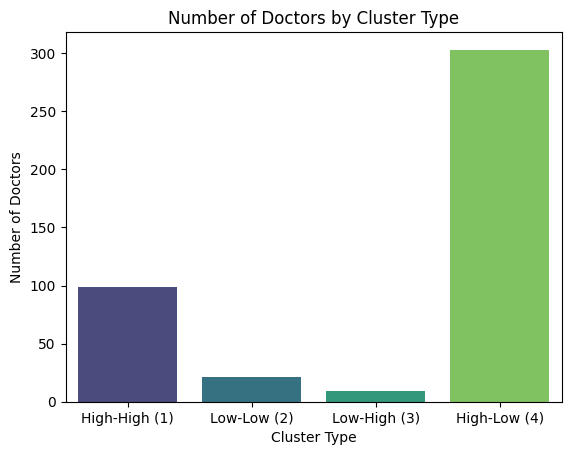

In [14]:
cluster_counts = moran_df['Cluster'].value_counts().sort_index()
print(cluster_counts)
# Create a bar plot
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Number of Doctors by Cluster Type')
plt.xlabel('Cluster Type')
plt.ylabel('Number of Doctors')
plt.xticks(ticks=[0, 1, 2, 3], labels=['High-High (1)', 'Low-Low (2)', 'Low-High (3)', 'High-Low (4)'])
plt.show()

High-High (1): high-degree doctors are surrounded by high-degree stations.\
Low-Low (2): low-degree doctors surrounded by low-degree stations.\
Low-High (3): low-degree doctors are near high-degree stations (spatial outliers).\
High-Low (4): high-degree doctors are near low-degree stations (spatial outliers).